# `godunov` — Lebacque's (1996) Godunov scheme + the Greenshields FD

**What.** `godunov` runs `ctm`'s cell update UNCHANGED on a GENERAL concave
fundamental diagram — here the smooth Greenshields (1935) parabola `Q(k) = vf *
k * (1 - k/kappa)` built from a link's `(vf, kappa)` — instead of the triangular
FD. `CTMLink`'s cell scheme was never triangular-specific: the Lebacque
`min(demand, supply)` flux is defined for any concave `Q`, so `GodunovLink`
substitutes a `GreenshieldsFD` for the link's default `TriangularFD` and reuses
the verified cell update as-is. It is the first non-triangular FD in the
benchmark, so it is the first to produce genuine RAREFACTION FANS (smooth
acceleration waves) — impossible on a piecewise-linear `Q`.

**Why it is in the benchmark.** At a transonic interface (`k_L > k_c > k_R`)
the Godunov flux `min(demand(k_L), supply(k_R))` returns the sonic-point
capacity `q_max` — the entropy-correct rarefaction value, not a shock value a
naive scheme could get wrong. See the
[model compendium](../../docs/MODELS.md) (Lebacque 1996) and
[docs/design/adr-018-godunov.md](../../docs/design/adr-018-godunov.md) (P1).

**Scope.** This notebook loads the built-in
`greenshields_bottleneck_dynamic_scenario` through `GodunovLink`, certifies it,
and recomputes the entropy-correct transonic flux directly from
`GreenshieldsFD` — the physics `ctm`'s triangular FD cannot produce.

**Canon.** `[lebacque1996godunov]`, [docs/REFERENCES.md](../../docs/REFERENCES.md) / [docs/references.bib](../../docs/references.bib).

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every
scored quantity below is recomputed live by the P1 `DNLEvaluator` from the
cumulative link curves the loader emitted, in the cell where it is claimed.
Godunov has no self-report to diff — like `ctm`/`ltm`, `NetworkLoader.run()` is
a deterministic, one-shot forward simulation
([README](../../README.md), *Certified, not self-reported*).

In [1]:
# Setup. `godunov` is a core DNL link model: a plain `pip install -e .` suffices
# — no optional extra, so no guard cell. The inline backend is Agg-based
# (headless CI renders into the notebook); NEVER matplotlib.use("Agg") in-kernel
# — it silently suppresses inline figure capture.
%matplotlib inline
import numpy as np
from scipy.optimize import brentq

from tabench import (
    DNLEvaluator,
    GodunovLink,
    GreenshieldsFD,
    NetworkLoader,
    greenshields_bottleneck_dynamic_scenario,
    viz,
)

## The scenario

The built-in `greenshields_bottleneck_dynamic_scenario`: a two-link corridor,
Greenshields-consistent on every link (`wave_speed = free_speed`,
`capacity = vf*kappa/4` — the constraint `GodunovLink` gates on). Upstream
`vf=1, kappa=8` (capacity 2) feeds a `vf=1, kappa=2` (capacity 0.5) bottleneck at
arrival rate 1.5: uncongested inflow above the bottleneck's capacity, so a queue
builds on the upstream link's PARABOLIC branch (distinct from `ctm`'s linear
one).

In [2]:
scenario = greenshields_bottleneck_dynamic_scenario()
net = scenario.network
dyn = scenario.dynamics
edges = scenario.grid.edges
print(f"scenario      : {scenario.name}")
print(f"content hash  : {scenario.content_hash()[:16]}…")
print(f"links         : {net.n_links}  (tail→head: "
      + ", ".join(f"{i}->{j}" for i, j in zip(net.init_node, net.term_node)) + ")")
print(f"link 0 (up)   : vf={dyn.free_speed[0]}, kappa={dyn.jam_density[0]}, "
      f"capacity={dyn.capacity[0]}  (vf*kappa/4 = {dyn.free_speed[0]*dyn.jam_density[0]/4})")
print(f"link 1 (sink) : vf={dyn.free_speed[1]}, kappa={dyn.jam_density[1]}, "
      f"capacity={dyn.capacity[1]}  (vf*kappa/4 = {dyn.free_speed[1]*dyn.jam_density[1]/4})")
print(f"grid          : dt={scenario.grid.dt}, n_steps={scenario.grid.n_steps}")

scenario      : dnl-greenshields-bottleneck
content hash  : 03afa86128008021…
links         : 2  (tail→head: 1->3, 3->2)
link 0 (up)   : vf=1.0, kappa=8.0, capacity=2.0  (vf*kappa/4 = 2.0)
link 1 (sink) : vf=1.0, kappa=2.0, capacity=0.5  (vf*kappa/4 = 0.5)
grid          : dt=1.0, n_steps=20


## Load the network

`GodunovLink` rebuilds a `GreenshieldsFD(vf, kappa)` from each link's declared
`(vf, kappa)` and runs `ctm`'s cell update on it unchanged; internally it is a
`CTMLink` subclass, so the SAME `NetworkLoader` contract applies.

In [3]:
loader = NetworkLoader(scenario, GodunovLink)
out = loader.run()
print(f"link model        : {GodunovLink.__name__}")
print(f"link 0 FD is Greenshields : {isinstance(loader.links[0].fd, GreenshieldsFD)}")
print(f"cells (link 0)     : {loader.links[0].n_cells}")
print(f"storage at t={edges[-1]:.0f}       : {out.n_in[0, -1] - out.n_out[0, -1]:.3f}")

link model        : GodunovLink
link 0 FD is Greenshields : True
cells (link 0)     : 4
storage at t=20       : 22.000


## Certify (P1) — feasibility, conservation, and the parabola's own roots

Beyond the structural gate (feasible, conservation, storage), the DISTINCTIVE
Godunov result: the upstream link's near-origin cell settles at the FREE branch
root of `Q(k) = 1.5` (the arrival rate), and its near-bottleneck cell settles at
the CONGESTED branch root of `supply(k) = 0.5` (the bottleneck capacity) — both
found here with `brentq` directly on `GreenshieldsFD`, the actual production FD,
not a hand-derived quadratic formula.

In [4]:
metrics = DNLEvaluator(scenario).evaluate(out)
print(f"dnl_feasible            : {metrics['dnl_feasible']:.0f}")
print(f"conservation_residual   : {metrics['conservation_residual']:.3e}")
print(f"storage_residual        : {metrics['storage_residual']:.3e}")
assert metrics["dnl_feasible"] == 1.0
assert metrics["conservation_residual"] <= 1e-9
assert metrics["storage_residual"] <= 1e-9

fd0 = GreenshieldsFD(vf=float(dyn.free_speed[0]), kappa=float(dyn.jam_density[0]))
k_free = brentq(lambda k: float(fd0.flow_at(np.array([k]))[0]) - 1.5, 0.0, fd0.critical_density)
k_cong = brentq(
    lambda k: float(fd0.supply_at(np.array([k]))[0]) - 0.5, fd0.critical_density, fd0.jam_density
)
print(f"free-branch root  Q(k)=1.5      : k_free = {k_free:.6f}")
print(f"congested-branch root supply=0.5: k_cong = {k_cong:.6f}")

dx = fd0.free_speed * scenario.grid.dt
density = loader.links[0].occupancy / dx
print(f"cell densities (upstream link)  : {np.round(density, 4)}")
# The far (origin-side) cell is still on the free branch; the near (bottleneck-
# side) cell has settled on the congested branch — both tight, no coarse-grid
# diffusion on these two constant-state cells.
assert abs(density[0] - k_free) < 1e-3
assert abs(density[-1] - k_cong) < 1e-3

dnl_feasible            : 1
conservation_residual   : 0.000e+00
storage_residual        : 0.000e+00
free-branch root  Q(k)=1.5      : k_free = 2.000000
congested-branch root supply=0.5: k_cong = 7.464102
cell densities (upstream link)  : [2.     5.0725 7.4634 7.4641]


## The distinctive physics: an entropy-correct rarefaction flux

A triangular FD's flux is piecewise LINEAR — it cannot produce a rarefaction
fan. The Greenshields parabola can: at a transonic interface (`k_L` above
critical, `k_R` below) the Godunov flux `min(demand(k_L), supply(k_R))` returns
the sonic-point capacity `q_max` — the entropy-correct value a naive
shock-speed formula would get wrong. Recomputed here directly from the FD, not
quoted.

In [5]:
fd = GreenshieldsFD(vf=2.0, kappa=4.0)  # q_max = 2, k_c = 2
k_l, k_r = 3.5, 0.5  # k_l > k_c > k_r: a transonic pair
flux = min(float(fd.demand_at(np.array([k_l]))[0]), float(fd.supply_at(np.array([k_r]))[0]))
print(f"fd: vf={fd.free_speed}, kappa={fd.jam_density}, k_c={fd.critical_density}, "
      f"q_max={fd.capacity}")
print(f"transonic flux at (k_L={k_l}, k_R={k_r}) : {flux:.6f}  (== q_max, not the shock value)")
assert abs(flux - fd.capacity) < 1e-9

fd: vf=2.0, kappa=4.0, k_c=2.0, q_max=2.0
transonic flux at (k_L=3.5, k_R=0.5) : 2.000000  (== q_max, not the shock value)


## Visualize

Both figures come from `tabench.viz`, the house visualizer. Left/top: the
certified network coloured by each link's time-averaged flow. Right/bottom: the
loaded average flow against the two analytic roots recomputed above, expressed
as an average flow anchor (`fd0.flow_at` at each recomputed root).

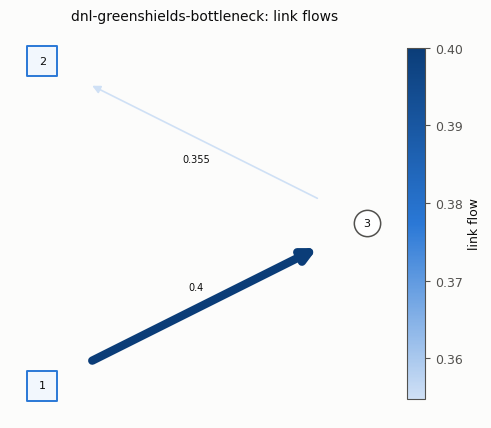

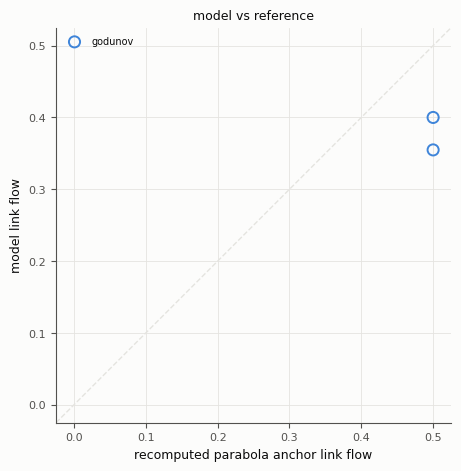

In [6]:
T = float(edges[-1])
avg_flow = out.n_out[:, -1] / T
ref_avg_flow = np.array([
    float(fd0.flow_at(np.array([k_cong]))[0]),  # upstream exit throttled to the bottleneck rate
    float(fd0.flow_at(np.array([k_cong]))[0]),  # sink link exits at the same steady rate
])

display(viz.plot_network_flows(net, avg_flow))
display(viz.plot_flow_scatter(("recomputed parabola anchor", ref_avg_flow), {"godunov": avg_flow}))

## Takeaways & pointers

- **Certified, not self-reported.** DNL link models have nothing to self-report
  — the boundary curves above ARE the emitted output, recertified from scratch
  by `DNLEvaluator`.
- **The Greenshields signature is the point.** `ctm`'s triangular envelope
  still majorizes it (so its certificates stay sound), but only a smooth,
  strictly concave FD produces the entropy-correct rarefaction flux certified
  above.
- **Where next.** the triangular baseline it reuses the cell scheme from
  [`ctm`](01-ctm.ipynb); the cumulative-curve alternative [`ltm`](02-ltm.ipynb);
  merges/diverges [`node-model`](04-node-model.ipynb); the lineage in the
  [model compendium](../../docs/MODELS.md).